In [107]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans, DBSCAN, AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
import hdbscan
import warnings
warnings.filterwarnings('ignore')

In [108]:
df = pd.read_csv('Mall_Customers.csv')

In [109]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


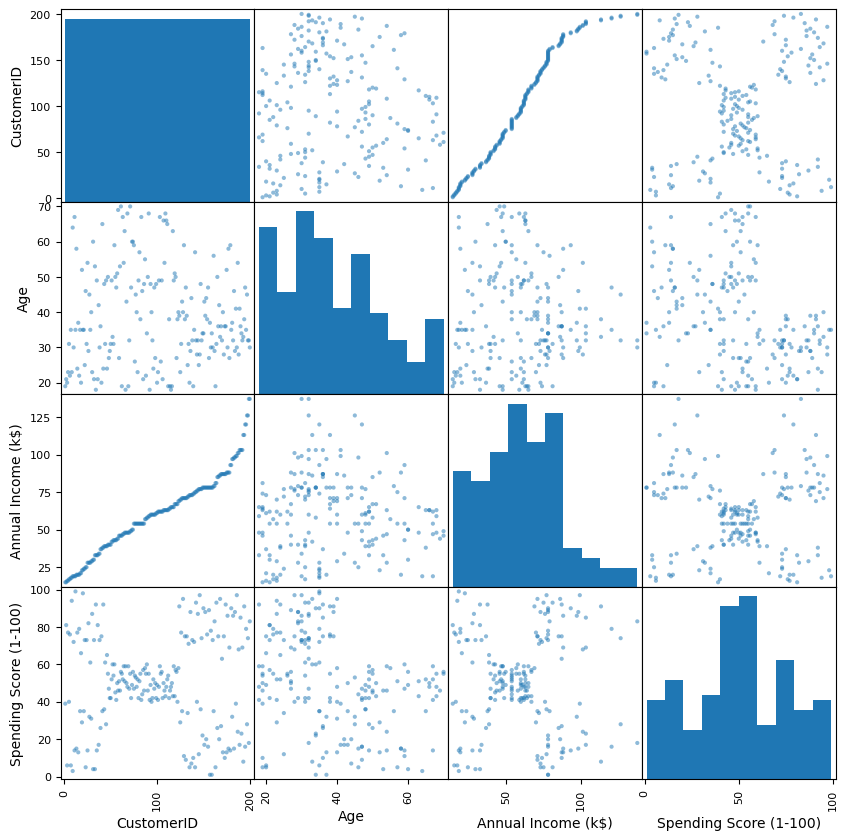

In [110]:
pd.plotting.scatter_matrix(df, figsize = (10,10))
plt.show()

In [127]:
X = df[['Age','Annual Income (k$)', 'Spending Score (1-100)']]
X

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40
...,...,...,...
195,35,120,79
196,45,126,28
197,32,126,74
198,32,137,18


# K Means Clustering

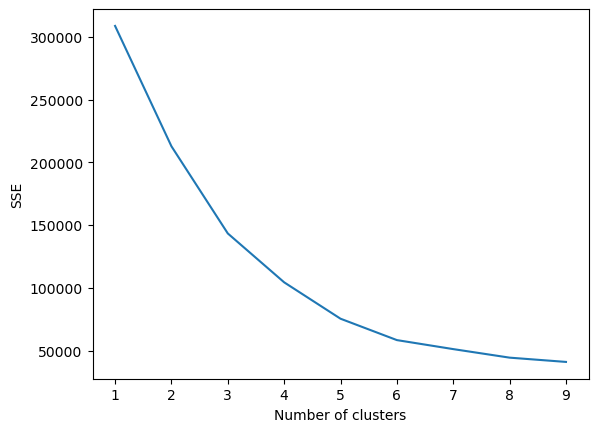

In [126]:
sse = []
for i in range(1, 10):
    km = KMeans(n_clusters =  i)
    km.fit(df[['Age','Annual Income (k$)', 'Spending Score (1-100)']])
    sse.append(km.inertia_)
plt.xlabel('Number of clusters')
plt.ylabel("SSE")
plt.plot(range(1,10), sse)

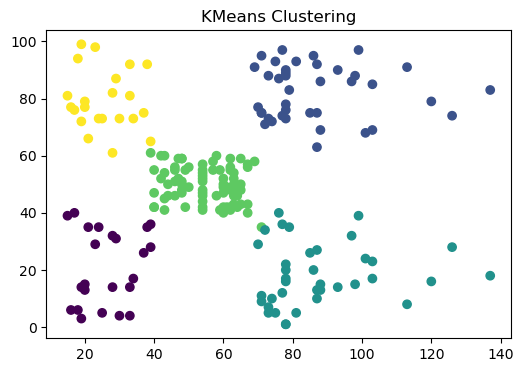

In [128]:
kmeans = KMeans(n_clusters=5, random_state=42)
kmeans_labels = kmeans.fit_predict(X)

plt.figure(figsize=(6, 4))
plt.scatter(X['Annual Income (k$)'], X['Spending Score (1-100)'], c=kmeans_labels, cmap='viridis')
plt.title("KMeans Clustering")
plt.show()


# Agglomerative Clustering

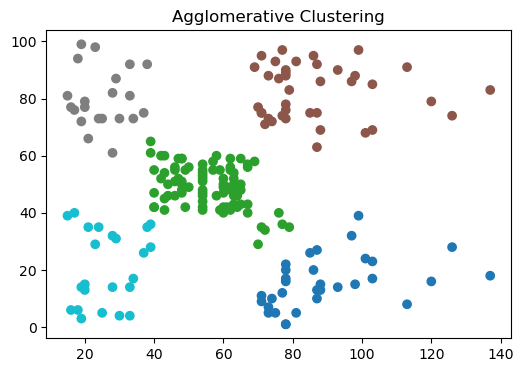

In [115]:
agg = AgglomerativeClustering(n_clusters=5)
agg_labels = agg.fit_predict(X)

plt.figure(figsize=(6, 4))
plt.scatter(X['Annual Income (k$)'], X['Spending Score (1-100)'], c=agg_labels, cmap='tab10')
plt.title("Agglomerative Clustering")
plt.show()


# DBSCAN Clustering

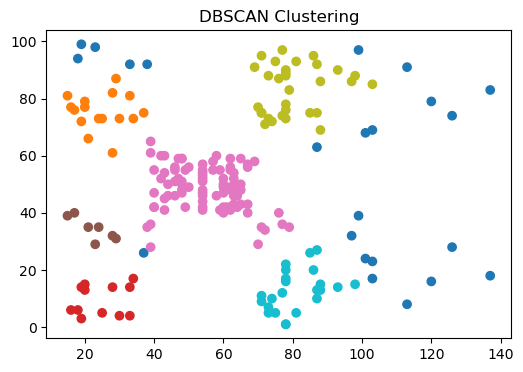

In [116]:
dbscan = DBSCAN(eps = 9, min_samples=5)
db_labels = dbscan.fit_predict(X)

plt.figure(figsize=(6, 4))
plt.scatter(X['Annual Income (k$)'], X['Spending Score (1-100)'], c=db_labels, cmap='tab10')
plt.title("DBSCAN Clustering")
plt.show()

# HDBSCAN Clustering

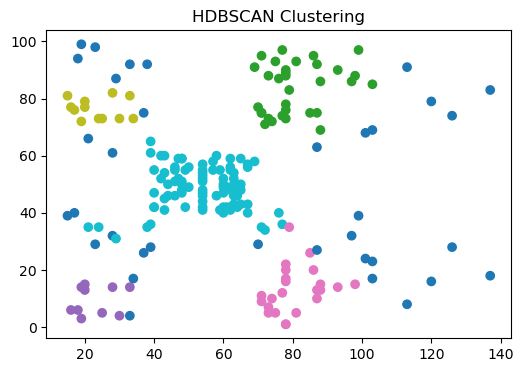

In [117]:
hdb = hdbscan.HDBSCAN(min_cluster_size=5)
hdb_labels = hdb.fit_predict(X)

plt.figure(figsize=(6, 4))
plt.scatter(X['Annual Income (k$)'], X['Spending Score (1-100)'], c=hdb_labels, cmap='tab10')
plt.title("HDBSCAN Clustering")
plt.show()

In [129]:
from sklearn.metrics import silhouette_score

print("KMeans Silhouette Score:", round(silhouette_score(X, kmeans_labels),3))
print("Agglomerative Silhouette Score:", round(silhouette_score(X, agg_labels),3))
print("DBSCAN Silhouette Score:", round(silhouette_score(X, db_labels),3))
print("HDBSCAN Silhouette Score:", round(silhouette_score(X, hdb_labels),3))


KMeans Silhouette Score: 0.444
Agglomerative Silhouette Score: 0.442
DBSCAN Silhouette Score: 0.31
HDBSCAN Silhouette Score: 0.28


In [122]:
# Apply PCA to reduce to 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Optional: check explained variance
print("Explained variance by PCA:", pca.explained_variance_ratio_)


Explained variance by PCA: [0.44266167 0.33308378]


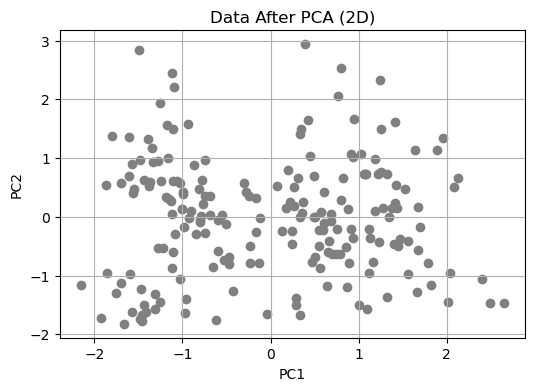

In [123]:
plt.figure(figsize=(6, 4))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c='gray')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('Data After PCA (2D)')
plt.grid(True)
plt.show()


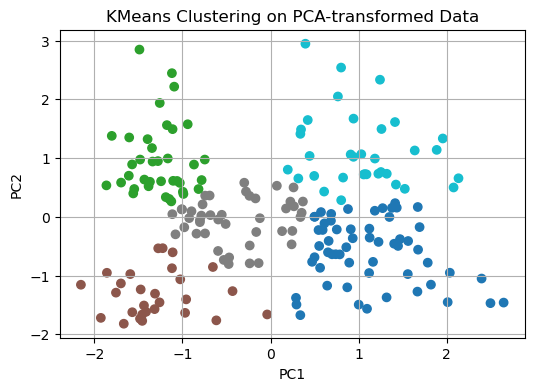

In [124]:
# KMeans on PCA data
kmeans_pca = KMeans(n_clusters=5, random_state=42)
kmeans_labels = kmeans_pca.fit_predict(X_pca)

# Plot clusters
plt.figure(figsize=(6, 4))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans_labels, cmap='tab10')
plt.title("KMeans Clustering on PCA-transformed Data")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.grid(True)
plt.show()
